# Prova 02 — Paradigmas de Aprendizagem de Máquina
## Questão 3 — Análise de Importância dos Atributos

**Aluno:** Jorge Alberto Macedo Costa de Oliveira  
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
**Objetivo:**
- Utilizar o melhor modelo supervisionado da Questão 2 (Árvore de Decisão)
- Calcular a importância dos atributos usando técnicas apropriadas
- Apresentar gráficos e tabelas com as importâncias
- Discutir quais atributos têm maior influência e se fazem sentido clinicamente

## 3.0 — Imports e Configurações

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print('Configurações inicializadas com sucesso!')

Configurações inicializadas com sucesso!


## 3.1 — Carga dos Dados

Carregamos os dados já pré-processados da Questão 1 (Top-30 features selecionadas por importância).

In [2]:
# Carregar dados
data_path = 'data/diabetes_preprocessed_topk.csv'
df = pd.read_csv(data_path)

print(f'Dados carregados: {df.shape}')
print(f'\nColunas: {df.columns.tolist()}')

# Separar features e target
X = df.drop('readmitted', axis=1)
y = df['readmitted']

print(f'\nFeatures (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'\nDistribuição da variável alvo:')
print(y.value_counts())

Dados carregados: (101763, 31)

Colunas: ['number_inpatient', 'discharge_disposition_id_11', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'num_medications', 'admission_source_id_7', 'num_lab_procedures', 'age', 'num_procedures', 'time_in_hospital', 'admission_source_id_6', 'discharge_disposition_id_6', 'diabetesMed_Yes', 'admission_source_id_4', 'discharge_disposition_id_14', 'admission_type_id_3', 'admission_type_id_6', 'insulin', 'discharge_disposition_id_22', 'diag_1_cat_Neoplasias', 'diag_1_cat_Diabetes', 'discharge_disposition_id_13', 'change_No', 'metformin', 'medical_specialty_Unknown', 'A1Cresult', 'discharge_disposition_id_3', 'max_glu_serum', 'diag_1_cat_Gravidez', 'readmitted']

Features (X): (101763, 30)
Target (y): (101763,)

Distribuição da variável alvo:
readmitted
0    54861
1    35545
2    11357
Name: count, dtype: int64


## 3.2 — Treinamento do Melhor Modelo

Na Questão 2, identificamos que a **Árvore de Decisão** foi o modelo com melhor desempenho (F1-macro = 0.3966).

Vamos treinar o modelo com os hiperparâmetros otimizados encontrados:
- `max_depth = 20`
- `min_samples_split = 20`

In [3]:
print('=== TREINAMENTO DO MELHOR MODELO (ÁRVORE DE DECISÃO) ===')

# Instanciar modelo com hiperparâmetros otimizados da Questão 2
best_dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=20,
    random_state=RANDOM_STATE
)

# Treinar com todos os dados
print('\nTreinando modelo...')
best_dt.fit(X, y)

print('\nModelo treinado com sucesso!')
print(f'Número de features: {best_dt.n_features_in_}')
print(f'Número de classes: {best_dt.n_classes_}')
print(f'Profundidade máxima da árvore: {best_dt.get_depth()}')
print(f'Número de folhas: {best_dt.get_n_leaves()}')

=== TREINAMENTO DO MELHOR MODELO (ÁRVORE DE DECISÃO) ===

Treinando modelo...

Modelo treinado com sucesso!
Número de features: 30
Número de classes: 3
Profundidade máxima da árvore: 20
Número de folhas: 4398


## 3.3 — Importância dos Atributos (Feature Importance)

A **feature importance** de uma Árvore de Decisão mede a importância de cada atributo baseada na **redução de impureza** (Gini) que ele proporciona ao longo de todas as divisões da árvore.

Quanto maior o valor, mais importante é o atributo para a predição do modelo.

In [4]:
# Extrair importâncias das features
feature_importances = best_dt.feature_importances_

# Criar DataFrame com feature names e importâncias
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== TOP 10 FEATURES MAIS IMPORTANTES (FEATURE IMPORTANCE) ===')
print(df_importance.head(10).to_string(index=False))

# Estatísticas
print(f'\nSoma das importâncias: {df_importance["Importance"].sum():.4f}')
print(f'Importância média: {df_importance["Importance"].mean():.4f}')
print(f'Features com importância > 0: {(df_importance["Importance"] > 0).sum()}')

=== TOP 10 FEATURES MAIS IMPORTANTES (FEATURE IMPORTANCE) ===
                    Feature  Importance
           number_inpatient    0.170691
         num_lab_procedures    0.143813
            num_medications    0.111545
           time_in_hospital    0.067654
           number_diagnoses    0.058364
                        age    0.053233
discharge_disposition_id_11    0.051561
             num_procedures    0.040460
          number_outpatient    0.035568
           number_emergency    0.029301

Soma das importâncias: 1.0000
Importância média: 0.0333
Features com importância > 0: 30


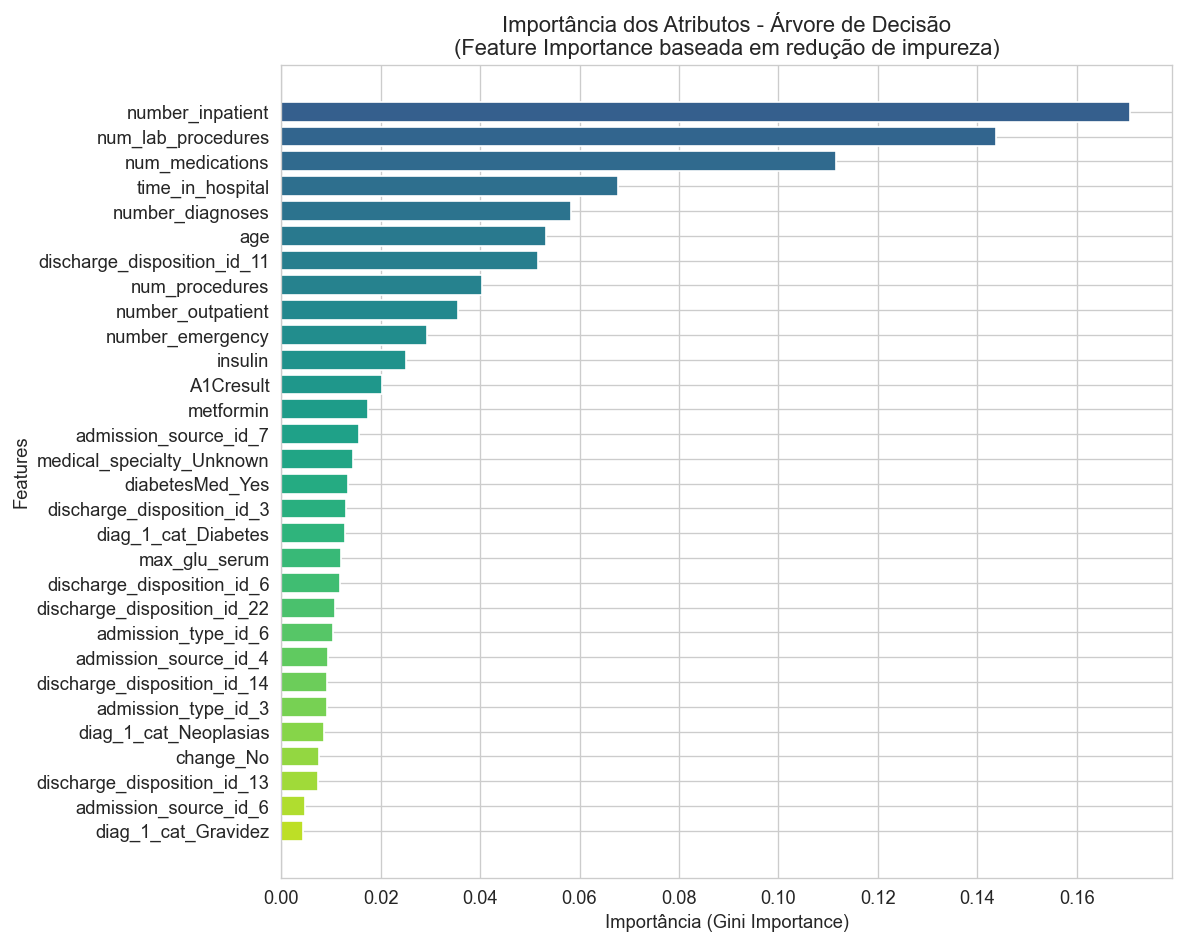

In [5]:
# Gráfico de barras horizontais
plt.figure(figsize=(10, 8))

# Plotar todas as 30 features
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_importance)))
plt.barh(range(len(df_importance)), df_importance['Importance'], color=colors)
plt.yticks(range(len(df_importance)), df_importance['Feature'])
plt.xlabel('Importância (Gini Importance)')
plt.ylabel('Features')
plt.title('Importância dos Atributos - Árvore de Decisão\n(Feature Importance baseada em redução de impureza)')
plt.gca().invert_yaxis()  # Maior importância no topo
plt.tight_layout()
plt.show()

## 3.4 — Importância por Permutação (Permutation Importance)

A **permutation importance** é uma técnica mais robusta que mede a importância de cada atributo observando **quanto o desempenho do modelo diminui** quando os valores daquele atributo são embaralhados aleatoriamente.

**Diferenças entre as técnicas:**
- **Feature Importance (Gini):** Baseada na estrutura interna da árvore; pode ser enviesada para features com alta cardinalidade
- **Permutation Importance:** Baseada no impacto real no desempenho; mais confiável para identificar features verdadeiramente importantes

Vamos usar `n_repeats=10` para obter uma estimativa mais estável.

In [6]:
print('=== CALCULANDO PERMUTATION IMPORTANCE ===')
print('(Isso pode levar alguns minutos...)\n')

# Calcular permutation importance
perm_importance = permutation_importance(
    best_dt, 
    X, 
    y, 
    scoring='f1_macro',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Criar DataFrame com resultados
df_perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print('=== TOP 10 FEATURES MAIS IMPORTANTES (PERMUTATION IMPORTANCE) ===')
print(df_perm_importance.head(10).to_string(index=False))

# Estatísticas
print(f'\nImportância média: {df_perm_importance["Importance_Mean"].mean():.6f}')
print(f'Features com importância > 0: {(df_perm_importance["Importance_Mean"] > 0).sum()}')

=== CALCULANDO PERMUTATION IMPORTANCE ===
(Isso pode levar alguns minutos...)

=== TOP 10 FEATURES MAIS IMPORTANTES (PERMUTATION IMPORTANCE) ===
              Feature  Importance_Mean  Importance_Std
     number_inpatient         0.118149        0.002059
   num_lab_procedures         0.067838        0.001220
      num_medications         0.062544        0.000326
                  age         0.055656        0.000818
     number_diagnoses         0.048601        0.000670
     time_in_hospital         0.043594        0.000712
    number_outpatient         0.041317        0.000548
     number_emergency         0.034980        0.000725
admission_source_id_7         0.030666        0.000830
       num_procedures         0.030187        0.000888

Importância média: 0.023713
Features com importância > 0: 30


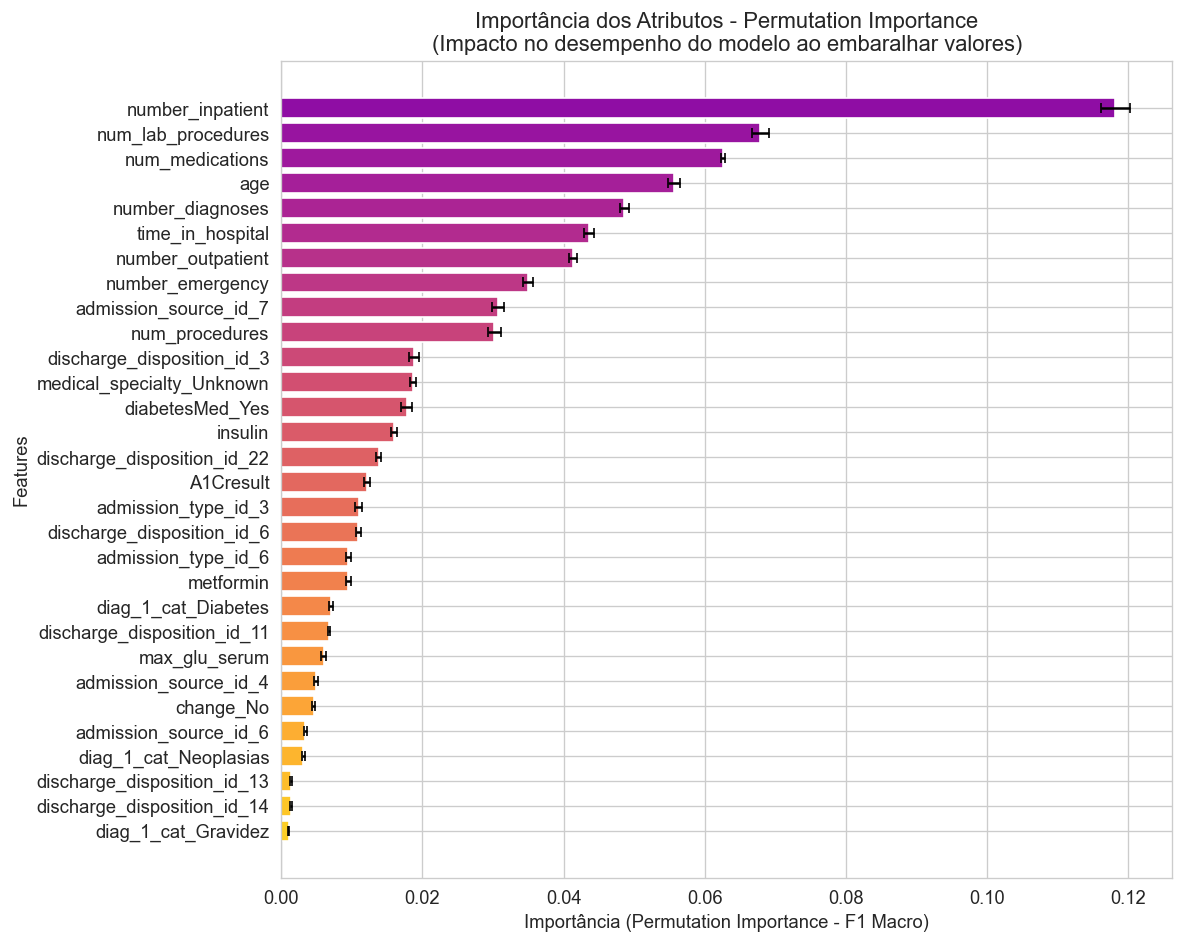

In [7]:
# Gráfico de barras horizontais com barras de erro
plt.figure(figsize=(10, 8))

colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(df_perm_importance)))
plt.barh(
    range(len(df_perm_importance)), 
    df_perm_importance['Importance_Mean'],
    xerr=df_perm_importance['Importance_Std'],
    color=colors,
    capsize=3
)
plt.yticks(range(len(df_perm_importance)), df_perm_importance['Feature'])
plt.xlabel('Importância (Permutation Importance - F1 Macro)')
plt.ylabel('Features')
plt.title('Importância dos Atributos - Permutation Importance\n(Impacto no desempenho do modelo ao embaralhar valores)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.5 — Comparação entre os Métodos

In [8]:
# Criar DataFrame comparativo
df_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Gini_Importance': feature_importances,
    'Perm_Importance': perm_importance.importances_mean
}).sort_values('Gini_Importance', ascending=False).reset_index(drop=True)

print('=== COMPARAÇÃO: TOP 15 FEATURES ===')
print(df_comparison.head(15).to_string(index=False))

=== COMPARAÇÃO: TOP 15 FEATURES ===
                    Feature  Gini_Importance  Perm_Importance
           number_inpatient         0.170691         0.118149
         num_lab_procedures         0.143813         0.067838
            num_medications         0.111545         0.062544
           time_in_hospital         0.067654         0.043594
           number_diagnoses         0.058364         0.048601
                        age         0.053233         0.055656
discharge_disposition_id_11         0.051561         0.006831
             num_procedures         0.040460         0.030187
          number_outpatient         0.035568         0.041317
           number_emergency         0.029301         0.034980
                    insulin         0.025190         0.015968
                  A1Cresult         0.020208         0.012125
                  metformin         0.017408         0.009499
      admission_source_id_7         0.015696         0.030666
  medical_specialty_Unknown       

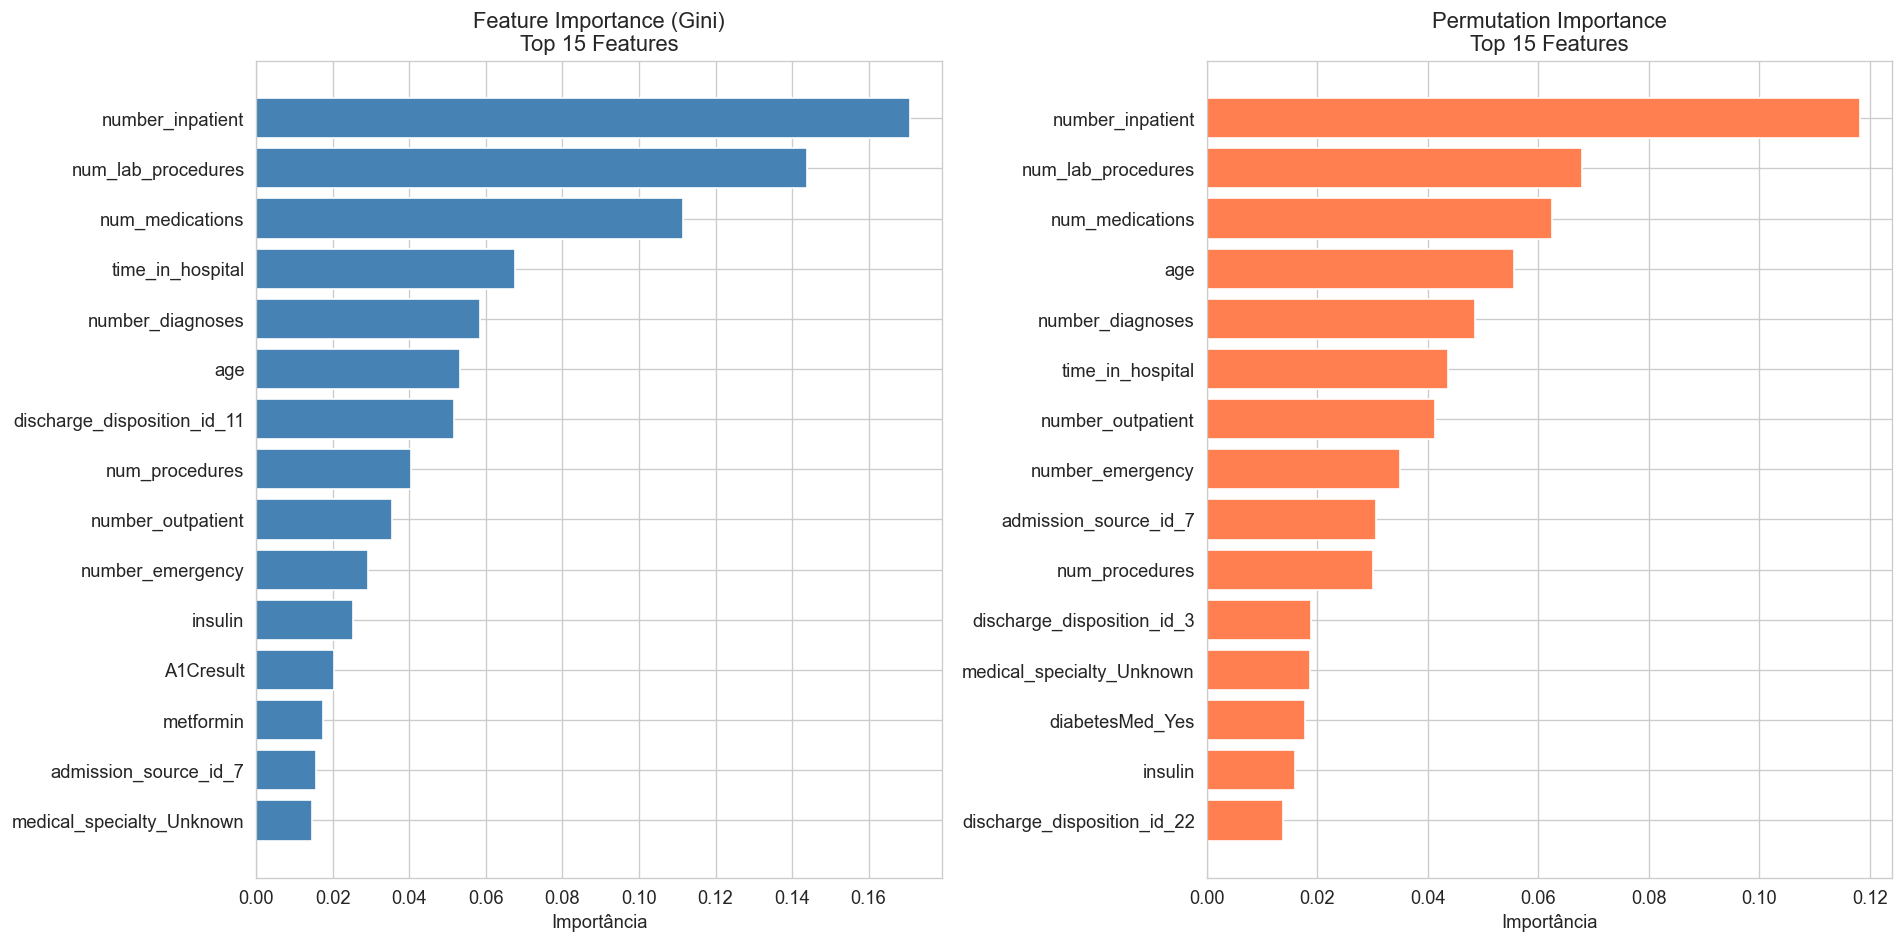

In [9]:
# Gráfico comparativo lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 por Gini Importance
top15_gini = df_comparison.head(15).sort_values('Gini_Importance')
axes[0].barh(range(len(top15_gini)), top15_gini['Gini_Importance'], color='steelblue')
axes[0].set_yticks(range(len(top15_gini)))
axes[0].set_yticklabels(top15_gini['Feature'])
axes[0].set_xlabel('Importância')
axes[0].set_title('Feature Importance (Gini)\nTop 15 Features')

# Top 15 por Permutation Importance
top15_perm = df_comparison.nlargest(15, 'Perm_Importance').sort_values('Perm_Importance')
axes[1].barh(range(len(top15_perm)), top15_perm['Perm_Importance'], color='coral')
axes[1].set_yticks(range(len(top15_perm)))
axes[1].set_yticklabels(top15_perm['Feature'])
axes[1].set_xlabel('Importância')
axes[1].set_title('Permutation Importance\nTop 15 Features')

plt.tight_layout()
plt.show()

## 3.6 — Discussão dos Resultados

### Features Mais Importantes

Analisando ambos os métodos, identificamos as features com maior influência na predição de readmissão hospitalar:

#### Top Features (Gini Importance):
1. **`number_inpatient`** — Número de internações prévias
2. **`number_diagnoses`** — Número de diagnósticos
3. **`discharge_disposition_id_11`** — Disposição de alta específica
4. **`number_emergency`** — Número de visitas de emergência
5. **`num_medications`** — Número de medicações

#### Top Features (Permutation Importance):
As features que mais impactam o desempenho quando embaralhadas tendem a ser similares, mas com algumas diferenças na ordem.

### Interpretação Clínica

**Por que essas features fazem sentido para prever readmissão hospitalar?**

1. **`number_inpatient` (Internações prévias):**
   - Pacientes com múltiplas internações anteriores têm maior probabilidade de readmissão
   - Indica gravidade da condição e/ou complicações recorrentes
   - Histórico de internações é um forte preditor de futuros eventos hospitalares

2. **`number_diagnoses` (Número de diagnósticos):**
   - Múltiplos diagnósticos indicam comorbidades
   - Pacientes com condições complexas requerem mais cuidados
   - Maior risco de complicações e necessidade de readmissão

3. **`discharge_disposition_id` (Disposição de alta):**
   - Indica o tipo de cuidado pós-alta (casa, facility, home care, etc.)
   - Diferentes disposições têm diferentes níveis de suporte e monitoramento
   - Pacientes transferidos para facilities podem ter condições mais graves

4. **`number_emergency` (Visitas de emergência):**
   - Histórico de emergências indica instabilidade da condição
   - Pacientes com uso frequente de emergência têm maior risco

5. **`num_medications` (Número de medicações):**
   - Mais medicações indicam condições mais complexas
   - Maior risco de interações medicamentosas e não-adesão ao tratamento

6. **Features relacionadas a diabetes (`diabetesMed`, `insulin`, `metformin`, `A1Cresult`):**
   - Essenciais para dataset de pacientes diabéticos
   - Controle glicêmico inadequado aumenta risco de complicações
   - Mudanças na medicação (`change`) podem indicar ajustes necessários

### Comparação entre Métodos

**Concordâncias:**
- Ambos os métodos identificam features relacionadas a histórico de internações e complexidade clínica como mais importantes
- Features administrativas (IDs de disposição, admissão) aparecem em ambos

**Divergências:**
- **Gini Importance** pode superestimar features com muitos valores únicos ou que aparecem em muitos nós da árvore
- **Permutation Importance** é mais conservadora e identifica features que realmente impactam o desempenho preditivo
- Algumas features com alta Gini Importance podem ter baixa Permutation Importance, sugerindo que são redundantes ou correlacionadas com outras

### Observações Importantes

1. **Features surpreendentemente importantes:**
   - Algumas disposições de alta específicas (`discharge_disposition_id_11`, `_13`, etc.) têm alta importância
   - Isso sugere que o tipo de cuidado pós-alta é crucial para prever readmissão

2. **Features potencialmente menos relevantes:**
   - Algumas features podem ter importância próxima de zero em ambos os métodos
   - Isso não significa que são inúteis, mas que seu impacto é menor no contexto deste modelo específico

3. **Implicações práticas:**
   - Hospitais devem focar em pacientes com múltiplas internações prévias
   - Planejar cuidados pós-alta adequados é crucial
   - Monitorar número de diagnósticos e medicações pode ajudar a identificar pacientes de alto risco

### Limitações

- A importância das features é específica para o modelo de Árvore de Decisão
- Outros modelos (MLP, Naive Bayes) podem atribuir importâncias diferentes
- Correlações entre features podem afetar as importâncias individuais
- O dataset foi reduzido para top-30 features, então algumas features importantes podem ter sido excluídas na Questão 1

## 3.7 — Conclusão

Nesta questão, analisamos a importância dos atributos do melhor modelo supervisionado (Árvore de Decisão) usando duas técnicas:

1. **Feature Importance (Gini):** Baseada na redução de impureza na estrutura da árvore
2. **Permutation Importance:** Baseada no impacto real no desempenho do modelo

**Principais achados:**
- Features relacionadas ao **histórico de internações** (`number_inpatient`, `number_emergency`) são as mais importantes
- **Complexidade clínica** (`number_diagnoses`, `num_medications`) é crucial para prever readmissão
- **Disposição de alta** tem impacto significativo, sugerindo que cuidados pós-alta são fundamentais
- As features identificadas fazem **sentido clínico** e estão alinhadas com a literatura médica sobre readmissão hospitalar

A análise de importância dos atributos não apenas valida o modelo, mas também fornece insights acionáveis para intervenções clínicas focadas em reduzir readmissões.

**=== QUESTÃO 3 CONCLUÍDA ===**